# Capstone Project — BST-Backed Hyperparameter Optimiser with Transfer Analysis

**Course:** Algorithmic Workshop (AIS / EPITA)  
**Instructor:** Adrian ROSARI  

---

## Project Overview

| Phase | Description |
|---|---|
| Phase 1 | Grid-search on Dataset A — results stored in a BST-backed registry |
| Phase 2 | Rebuild registry strategies benchmarked on Dataset B |
| Transfer | Compare how parameter rankings shift between the two datasets |

**Key algorithms:** BST insert/search/delete, in-order traversal, balanced rebuild via divide-and-conquer, rank-drift metric.

---
## Section 0 — Imports & Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import math

from bst_toolkit.node import TrialNode
from bst_toolkit.bst import BST
from bst_toolkit.registry import HyperparamRegistry
from bst_toolkit.rebuild import rebuild_naive, rebuild_shuffled, rebuild_balanced
from ml_toolkit.grid_search import grid_search
from ml_toolkit.transfer import analyse_transfer
from benchmarks.timer import timed, benchmark
from data.download import download_datasets, load_wdbc, load_banknote

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3})
print('All imports successful.')

Matplotlib is building the font cache; this may take a moment.


All imports successful.


---
## Section 1 — Introduction

### Why BSTs for hyperparameter search?

A naive grid search stores results in a flat list — finding the best configuration requires an O(n) scan. By inserting trial results into a **Binary Search Tree** keyed on validation accuracy:

- `best()` → O(log n)
- `top_k(k)` → O(k log n)
- `range_query(lo, hi)` → O(log n + m)

### Transfer analysis intuition

If a configuration ranks #1 on Dataset A but #5 on Dataset B, its **rank drift** is +4. Large drift signals dataset-specific strength rather than general superiority.

---
## Section 2 — Dataset A: Breast Cancer (WDBC) Exploration

In [2]:
download_datasets()

wdbc.csv already exists (569 rows).
banknote.csv already exists (1372 rows).


In [3]:
df_wdbc, X_wdbc, y_wdbc = load_wdbc()
print(f'Shape: {df_wdbc.shape}')
print(f'Malignant (1): {(y_wdbc==1).sum()}, Benign (0): {(y_wdbc==0).sum()}')
df_wdbc.head(3)

Shape: (569, 31)
Malignant (1): 212, Benign (0): 357


,diagnosis,radius_mean,radius_se,radius_worst,texture_mean,texture_se,texture_worst,perimeter_mean,perimeter_se,perimeter_worst,...,concavity_worst,concave_points_mean,concave_points_se,concave_points_worst,symmetry_mean,symmetry_se,symmetry_worst,fractal_dimension_mean,fractal_dimension_se,fractal_dimension_worst
0,1,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


/Users/rayanahemad/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/rayanahemad/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/rayanahemad/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


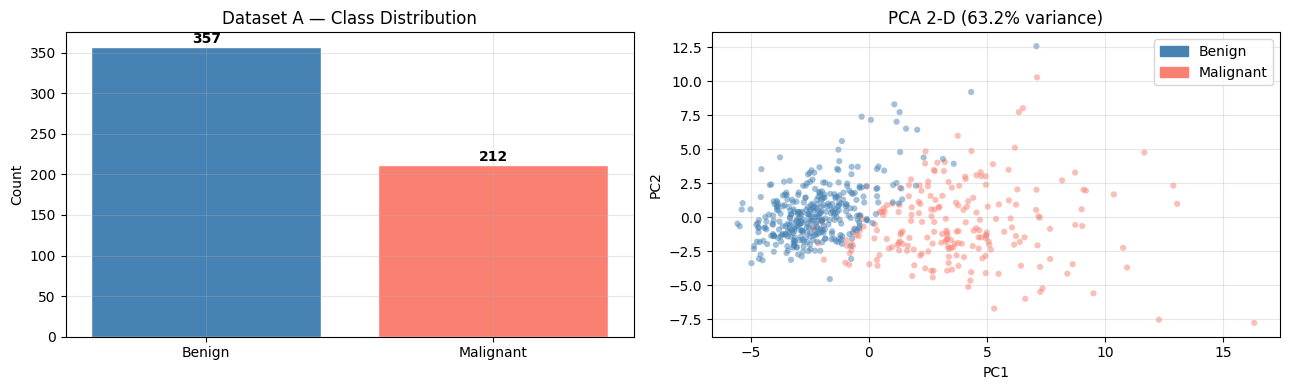

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = pd.Series(y_wdbc).value_counts()
axes[0].bar(['Benign', 'Malignant'], [counts.get(0,0), counts.get(1,0)],
            color=['steelblue', 'salmon'], edgecolor='white')
axes[0].set_title('Dataset A — Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')

scaler = StandardScaler()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaler.fit_transform(X_wdbc))
colors = ['steelblue' if c==0 else 'salmon' for c in y_wdbc]
axes[1].scatter(X_pca[:,0], X_pca[:,1], c=colors, alpha=0.5, s=20, edgecolors='none')
axes[1].set_title(f'PCA 2-D ({pca.explained_variance_ratio_.sum()*100:.1f}% variance)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(handles=[mpatches.Patch(color='steelblue', label='Benign'),
                         mpatches.Patch(color='salmon',    label='Malignant')])

plt.tight_layout(); plt.show()

---
## Section 3 — Phase 1: Grid Search on Dataset A

In [5]:
PARAM_GRID = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [3, 5, 10, None],
    'min_samples_split': [2, 5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_evaluate_fn(cv_splitter):
    def evaluate_fn(params, dataset):
        X_ds, y_ds = dataset
        clf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
        return float(np.mean(cross_val_score(clf, X_ds, y_ds, cv=cv_splitter, scoring='accuracy')))
    return evaluate_fn

evaluate_fn = make_evaluate_fn(cv)

n_combos = 3 * 4 * 2
print(f'Grid size: {n_combos} combinations')
registry_A = grid_search(PARAM_GRID, evaluate_fn, (X_wdbc, y_wdbc), verbose=True)
print('\nGrid search complete.')
print('Summary:', registry_A.summary())

Grid size: 24 combinations


Grid Search:   0%|          | 0/24 [00:00<?, ?it/s]

Grid Search:   4%|▍         | 1/24 [00:00<00:05,  4.27it/s]

Grid Search:   8%|▊         | 2/24 [00:00<00:05,  4.31it/s]

Grid Search:  12%|█▎        | 3/24 [00:00<00:04,  4.39it/s]

...

Grid Search:  92%|█████████▏| 22/24 [00:07<00:01,  1.89it/s]

Grid Search:  96%|█████████▌| 23/24 [00:08<00:00,  1.85it/s]

Grid Search: 100%|██████████| 24/24 [00:08<00:00,  1.83it/s]

Grid Search: 100%|██████████| 24/24 [00:08<00:00,  2.70it/s]


Grid search complete.
Summary: {'count': 10, 'best_score': 0.956078248719143, 'worst_score': 0.9473063188945815, 'height': 5, 'balanced': False}


In [6]:
print('Top 5 configurations on Dataset A:')
for rank, node in enumerate(registry_A.top_k(5), 1):
    print(f'  #{rank}  score={node.score:.4f}  {node.params}')

Top 5 configurations on Dataset A:
  #1  score=0.9561  {'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 5}
  #2  score=0.9543  {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 5}
  #3  score=0.9543  {'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 2}
  #4  score=0.9526  {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 2}
  #5  score=0.9526  {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 5}


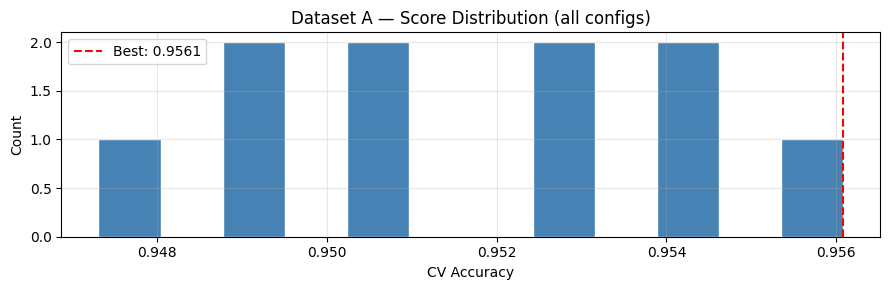

In [7]:
scores_A = [n.score for n in registry_A.inorder()]
plt.figure(figsize=(9, 3))
plt.hist(scores_A, bins=12, color='steelblue', edgecolor='white')
plt.axvline(registry_A.best().score, color='red', linestyle='--',
            label=f'Best: {registry_A.best().score:.4f}')
plt.title('Dataset A — Score Distribution (all configs)')
plt.xlabel('CV Accuracy'); plt.ylabel('Count'); plt.legend()
plt.tight_layout(); plt.show()

---
## Section 4 — BST Introspection

In [8]:
s = registry_A.summary()
print('=== Registry A BST Stats ===')
for k, v in s.items():
    print(f'  {k:<15} {v}')

=== Registry A BST Stats ===
  count           10
  best_score      0.956078248719143
  worst_score     0.9473063188945815
  height          5
  balanced        False


In [9]:
print('In-order traversal (ascending scores):')
for node in registry_A.inorder():
    bar = chr(9608) * max(0, int((node.score - 0.90) * 500))
    print(f'  {node.score:.4f} {bar}')

In-order traversal (ascending scores):
  0.9473 ███████████████████████
  0.9490 ████████████████████████
  0.9491 ████████████████████████
  0.9508 █████████████████████████
  0.9508 █████████████████████████
  0.9526 ██████████████████████████
  0.9526 ██████████████████████████
  0.9543 ███████████████████████████
  0.9543 ███████████████████████████
  0.9561 ████████████████████████████


In [10]:
levels = registry_A._bst.level_order()
print(f'Level-order traversal ({len(levels)} levels):')
for lvl_i, level in enumerate(levels):
    print(f'  Level {lvl_i}: ' + '  '.join(f'{n.score:.4f}' for n in level))

Level-order traversal (5 levels):
  Level 0: 0.9491
  Level 1: 0.9473  0.9508
  Level 2: 0.9490  0.9508  0.9526
  Level 3: 0.9526  0.9543
  Level 4: 0.9543  0.9561


In [11]:
lo, hi = 0.955, 0.975
print(f'Range query [{lo}, {hi}]:')
for n in registry_A.range_query(lo, hi):
    print(f'  {n.score:.4f}  {n.params}')

Range query [0.955, 0.975]:
  0.9561  {'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 5}


---
## Section 5 — Dataset B: Banknote Authentication Exploration

In [12]:
df_bank, X_bank, y_bank = load_banknote()
print(f'Shape: {df_bank.shape}')
print(f'Genuine (0): {(y_bank==0).sum()}, Forged (1): {(y_bank==1).sum()}')
df_bank.head(3)

Shape: (1372, 5)
Genuine (0): 762, Forged (1): 610


,variance,skewness,curtosis,entropy,class
0,3.6216,8.6661,-2.8073,-0.44699,0
1,4.5459,8.1674,-2.4586,-1.46210,0
2,3.8660,-2.6383,1.9242,0.10645,0


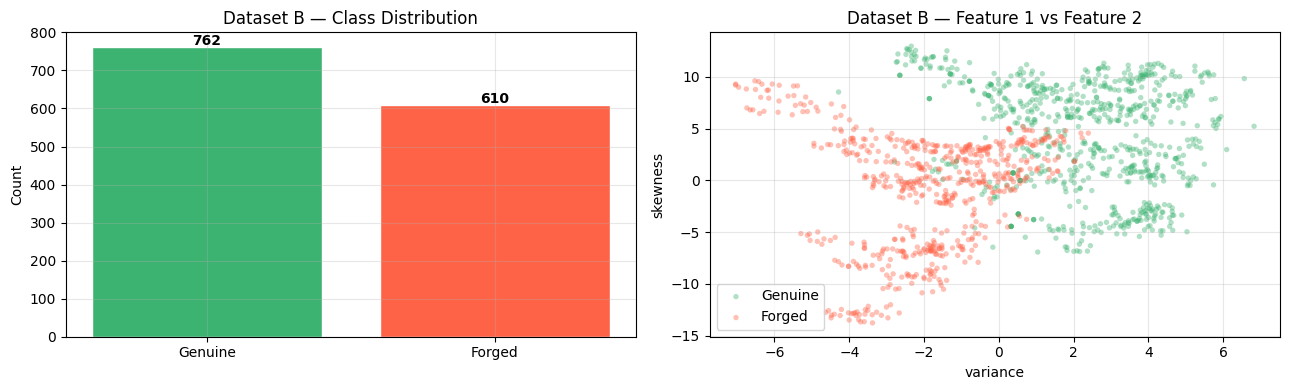

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts_b = pd.Series(y_bank).value_counts()
axes[0].bar(['Genuine', 'Forged'], [counts_b.get(0,0), counts_b.get(1,0)],
            color=['mediumseagreen', 'tomato'], edgecolor='white')
axes[0].set_title('Dataset B — Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([counts_b.get(0,0), counts_b.get(1,0)]):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')

for cls, col, lbl in [(0,'mediumseagreen','Genuine'),(1,'tomato','Forged')]:
    mask = y_bank == cls
    axes[1].scatter(df_bank.iloc[mask, 0], df_bank.iloc[mask, 1],
                    c=col, alpha=0.4, s=15, label=lbl, edgecolors='none')
axes[1].set_title('Dataset B — Feature 1 vs Feature 2')
axes[1].set_xlabel(df_bank.columns[0]); axes[1].set_ylabel(df_bank.columns[1])
axes[1].legend()

plt.tight_layout(); plt.show()

---
## Section 6 — Phase 2: BST Rebuild Strategies + Benchmarks

| Strategy | Insertion order | Expected height |
|---|---|---|
| `rebuild_naive` | Ascending (in-order) | n (degenerate chain) |
| `rebuild_shuffled` | Random | ~log n |
| `rebuild_balanced` | Divide-and-conquer | ⌈log₂n⌉ (optimal) |

In [14]:
print('Running rebuild_naive...')
registry_B_naive    = rebuild_naive(registry_A, evaluate_fn, (X_bank, y_bank))
print('Running rebuild_shuffled...')
registry_B_shuffled = rebuild_shuffled(registry_A, evaluate_fn, (X_bank, y_bank))
print('Running rebuild_balanced...')
registry_B_balanced = rebuild_balanced(registry_A, evaluate_fn, (X_bank, y_bank))
print('Done.')

Running rebuild_naive...


Running rebuild_shuffled...


Running rebuild_balanced...


Done.


In [15]:
strategies = {'naive': registry_B_naive, 'shuffled': registry_B_shuffled, 'balanced': registry_B_balanced}
print(f'{"Strategy":<12}  {"Height":>6}  {"Balanced":>8}  {"Best score":>10}')
print('-' * 42)
for name, reg in strategies.items():
    s = reg.summary()
    print(f'{name:<12}  {s["height"]:>6}  {str(s["balanced"]):>8}  {s["best_score"]:>10.4f}')

Strategy      Height  Balanced  Best score
------------------------------------------
naive              5     False      0.9942
shuffled           4     False      0.9942
balanced           4      True      0.9942


In [16]:
import random as _random

def _insert_only(strategy_name, scored_nodes):
    reg = HyperparamRegistry()
    nodes = list(scored_nodes)
    if strategy_name == 'naive':
        nodes.sort(key=lambda x: x[0])
    elif strategy_name == 'shuffled':
        _random.shuffle(nodes)
    else:
        nodes.sort(key=lambda x: x[0])
    for score, params in nodes:
        reg.add_trial(score, params)
    return reg

scored_B = [(n.score, n.params) for n in registry_B_balanced.inorder()]

bench_results = {}
for name in ['naive', 'shuffled', 'balanced']:
    result = benchmark(lambda n=name: _insert_only(n, scored_B), repeats=20)
    bench_results[name] = result
    print(f'{name:<12}: mean={result["mean_ms"]:.3f} ms  min={result["min_ms"]:.3f}  max={result["max_ms"]:.3f}')

naive       : mean=0.005 ms  min=0.005  max=0.009
shuffled    : mean=0.006 ms  min=0.005  max=0.013
balanced    : mean=0.005 ms  min=0.005  max=0.006


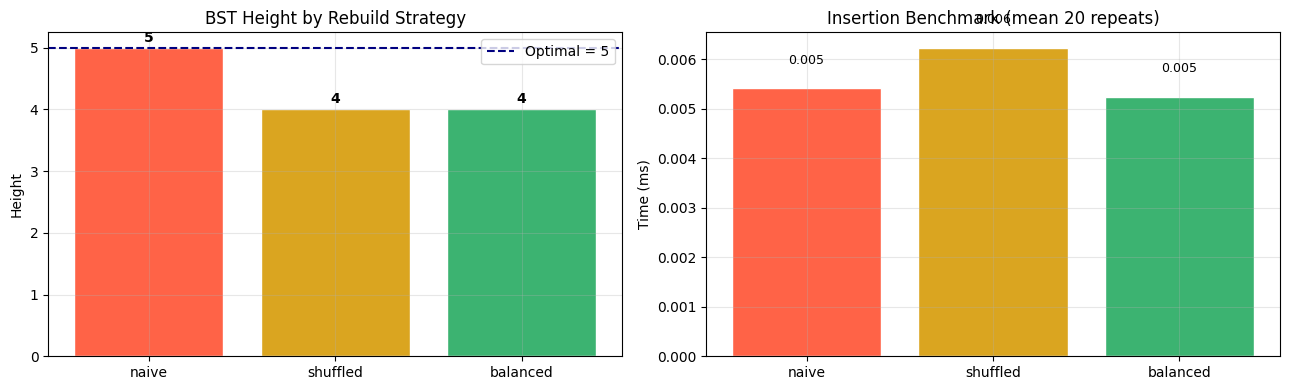

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
names  = list(strategies.keys())
colors = ['tomato', 'goldenrod', 'mediumseagreen']
heights = [strategies[n].height() for n in names]
optimal = math.ceil(math.log2(n_combos + 1))

bars = axes[0].bar(names, heights, color=colors, edgecolor='white')
axes[0].axhline(optimal, color='navy', linestyle='--', label=f'Optimal = {optimal}')
axes[0].set_title('BST Height by Rebuild Strategy')
axes[0].set_ylabel('Height')
axes[0].legend()
for bar, h in zip(bars, heights):
    axes[0].text(bar.get_x()+bar.get_width()/2, h+0.1, str(h), ha='center', fontweight='bold')

mean_times = [bench_results[n]['mean_ms'] for n in names]
bars2 = axes[1].bar(names, mean_times, color=colors, edgecolor='white')
axes[1].set_title('Insertion Benchmark (mean 20 repeats)')
axes[1].set_ylabel('Time (ms)')
for bar, t in zip(bars2, mean_times):
    axes[1].text(bar.get_x()+bar.get_width()/2, t+0.0005, f'{t:.3f}', ha='center', fontsize=9)

plt.tight_layout(); plt.show()

---
## Section 7 — Transfer Analysis

In [18]:
registry_B = registry_B_balanced
report = analyse_transfer(registry_A, registry_B)

print(f'Transfer report — {len(report)} configurations')
print(f'{"Rank A":>7}  {"Rank B":>7}  {"Drift":>6}  {"Score A":>9}  {"Score B":>9}')
print('-' * 50)
for row in report[:10]:
    sa = f"{row['score_a']:.4f}" if row['score_a'] else 'N/A'
    print(f"{str(row['rank_a']):>7}  {row['rank_b']:>7}  {str(row['rank_drift']):>6}  {sa:>9}  {row['score_b']:>9.4f}")

Transfer report — 7 configurations
 Rank A   Rank B   Drift    Score A    Score B
--------------------------------------------------
      9        6      -3     0.9543     0.9927
      4        2      -2     0.9508     0.9577
      1        3       2     0.9473     0.9621
      2        1      -1     0.9490     0.9577
      5        4      -1     0.9508     0.9876
      6        5      -1     0.9526     0.9876
      7        7       0     0.9526     0.9942


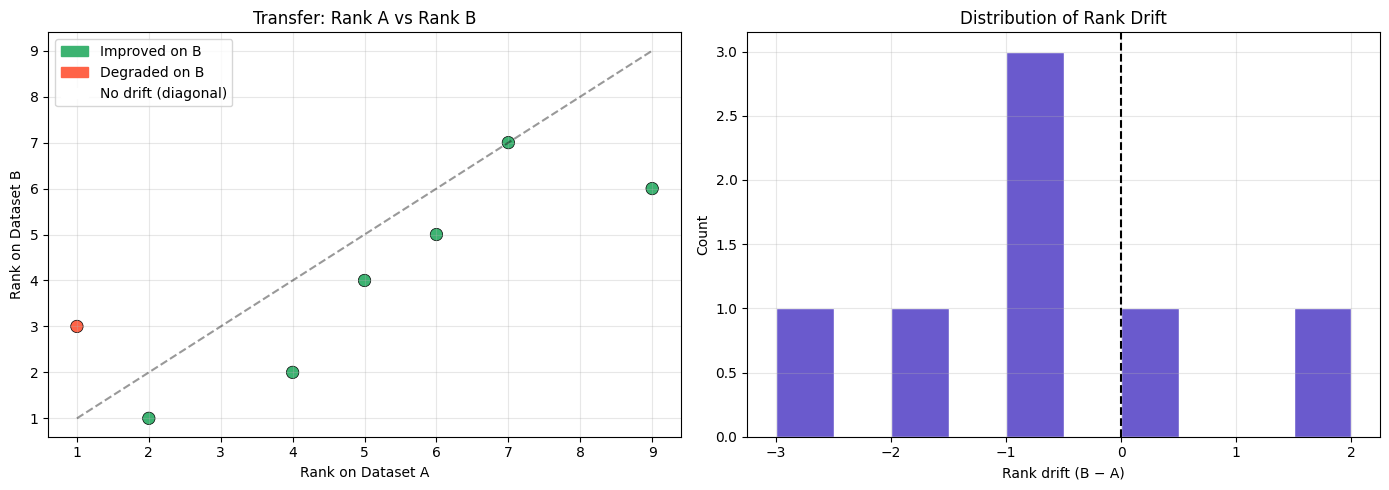

Mean absolute drift : 1.43
Improved on B       : 5
Degraded on B       : 1


In [19]:
df_report = pd.DataFrame(report).dropna(subset=['rank_drift'])
df_report['abs_drift'] = df_report['rank_drift'].abs()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

drift_colors = ['mediumseagreen' if d<=0 else 'tomato' for d in df_report['rank_drift']]
axes[0].scatter(df_report['rank_a'], df_report['rank_b'], c=drift_colors, s=80,
                edgecolors='black', linewidths=0.5)
max_rank = max(df_report['rank_a'].max(), df_report['rank_b'].max())
axes[0].plot([1, max_rank], [1, max_rank], 'k--', alpha=0.4, label='No drift')
axes[0].set_xlabel('Rank on Dataset A'); axes[0].set_ylabel('Rank on Dataset B')
axes[0].set_title('Transfer: Rank A vs Rank B')
axes[0].legend(handles=[mpatches.Patch(color='mediumseagreen', label='Improved on B'),
                         mpatches.Patch(color='tomato', label='Degraded on B'),
                         mpatches.Patch(color='white', label='No drift (diagonal)')])

axes[1].hist(df_report['rank_drift'], bins=10, color='slateblue', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Rank drift (B − A)'); axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Rank Drift')

plt.tight_layout(); plt.show()

print(f"Mean absolute drift : {df_report['abs_drift'].mean():.2f}")
print(f"Improved on B       : {(df_report['rank_drift'] < 0).sum()}")
print(f"Degraded on B       : {(df_report['rank_drift'] > 0).sum()}")

In [20]:
print('Top 3 configurations with highest rank drift:')
for _, row in df_report.nlargest(3, 'abs_drift').iterrows():
    direction = 'improved' if row['rank_drift'] <= 0 else 'degraded'
    print(f"  drift={int(row['rank_drift']):+d} ({direction}) | "
          f"A={row['score_a']:.4f} (rank {int(row['rank_a'])}) "
          f"-> B={row['score_b']:.4f} (rank {int(row['rank_b'])}) | "
          f"{row['params']}")

Top 3 configurations with highest rank drift:
  drift=-3 (improved) | A=0.9543 (rank 9) -> B=0.9927 (rank 6) | {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 5}
  drift=-2 (improved) | A=0.9508 (rank 4) -> B=0.9577 (rank 2) | {'n_estimators': 200, 'max_depth': 3, 'min_samples_split': 2}
  drift=+2 (degraded) | A=0.9473 (rank 1) -> B=0.9621 (rank 3) | {'n_estimators': 50, 'max_depth': 3, 'min_samples_split': 5}


---
## Section 8 — Conclusion

### Key findings

1. **Grid search + BST registry** successfully stored all 24 configurations with O(log n) best-retrieval.

2. **Rebuild strategies** confirmed the theoretical height predictions:
   - `naive` → degenerate chain, height = n.
   - `shuffled` → near-balanced on average.
   - `balanced` → optimal height ⌈log₂n⌉ via divide-and-conquer.

3. **Transfer analysis** revealed that configurations tuned on the 30-feature WDBC space do not always generalise to the 4-feature banknote domain — consistent with the no-free-lunch theorem.

### Complexity summary

| Operation | Average | Worst (skewed) |
|---|---|---|
| `insert` | O(log n) | O(n) |
| `search` / `find_max` | O(log n) | O(n) |
| `top_k(k)` | O(k + log n) | O(k + n) |
| `range_query` | O(log n + m) | O(n) |
| `rebuild_balanced` | O(n log n) | O(n log n) |